# Smart MCQ Solver

Three models are trained and compared using accuracy, macro-F1, and MAP@3.  
The final Kaggle submission is produced only from trained-model probabilities, without rule-based answer replacement.

## Setup
Remove optional libraries that caused CUDA and torchvision conflicts. Install only WandB and SentencePiece, then run the notebook from top to bottom in a fresh Kaggle session.

In [1]:
# Remove packages not required by this notebook
!pip uninstall -y -q torchvision torchaudio peft bitsandbytes

# Keep Kaggle's existing Torch, Transformers, NumPy and scikit-learn
!pip install -q --no-cache-dir wandb sentencepiece

print("Setup complete. Continue with the next cell.")

Setup complete. Continue with the next cell.


## Imports and settings
NumPy handles arrays, Pandas manages tables, Matplotlib plots graphs, and PyTorch builds the models.
The remaining imports support data splitting, metrics, tokenization, and reproducibility.

In [2]:
import os
import re
import gc
import random
import warnings
from collections import Counter, defaultdict
from dataclasses import dataclass
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score

import transformers

warnings.filterwarnings("ignore")

SEED = 42
OPTIONS = list("ABCDE")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128
Transformers: 5.0.0
Device: cuda
GPU: Tesla T4


### Run the next step
This cell executes the next part of the pipeline: `import torch`.  
Its output confirms that the required variables or files were created.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

## WandB connection
Connect WandB using the Kaggle secret and set the project name.
The output shows whether experiment tracking is active or disabled.

In [4]:
import wandb

WANDB_PROJECT = "smart-mcq-solver"
WANDB_ENABLED = False

try:
    from kaggle_secrets import UserSecretsClient

    api_key = UserSecretsClient().get_secret("WANDB_API_KEY")
    wandb.login(key=api_key, relogin=True)
    WANDB_ENABLED = True
    print("WandB connected")
except Exception as error:
    print("WandB disabled:", str(error)[:120])

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 23f2004693 (23f2004693-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WandB connected


## Load the data
Find the train, test, and sample submission files, then read them with Pandas.
The printed shapes show the number of rows and columns in each file.

In [5]:
def find_file(filename):
    matches = []
    for root, _, files in os.walk("/kaggle/input"):
        if filename in files:
            matches.append(os.path.join(root, filename))
    if not matches:
        raise FileNotFoundError(f"{filename} was not found under /kaggle/input")
    return matches[0]

train_df = pd.read_csv(find_file("train.csv"))
test_df = pd.read_csv(find_file("test.csv"))
sample_submission = pd.read_csv(find_file("sample_submission.csv"))

required_train = {"prompt", "A", "B", "C", "D", "E", "answer"}
required_test = {"prompt", "A", "B", "C", "D", "E"}
assert required_train.issubset(train_df.columns)
assert required_test.issubset(test_df.columns)

print("Train:", train_df.shape)
print("Test:", test_df.shape)
display(train_df.head())

Train: (2000, 8)
Test: (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


## Text cleaning and metrics
Create text-cleaning functions, a prompt-group split, and evaluation metrics.
The output shows the train and validation sizes and confirms that repeated prompts stay in one split.

In [6]:
def clean_text(value):
    value = str(value).strip()
    value = re.sub(r"\s+", " ", value)
    return value

def normalize_text(value):
    value = clean_text(value).lower()
    value = re.sub(r"[^a-z0-9 ]+", "", value)
    return re.sub(r"\s+", " ", value).strip()

for df in (train_df, test_df):
    for column in ["prompt"] + OPTIONS:
        df[column] = df[column].map(clean_text)

def map_at_3(actual, rankings):
    values = []
    for answer, ranking in zip(actual, rankings):
        top3 = ranking[:3]
        values.append(1.0 / (top3.index(answer) + 1) if answer in top3 else 0.0)
    return float(np.mean(values))

def score_rankings(actual, rankings):
    top1 = [ranking[0] for ranking in rankings]
    return {
        "accuracy": accuracy_score(actual, top1),
        "f1_macro": f1_score(actual, top1, labels=OPTIONS, average="macro", zero_division=0),
        "map3": map_at_3(actual, rankings),
    }

groups = train_df["prompt"].map(normalize_text)
splitter = GroupShuffleSplit(n_splits=1, test_size=0.18, random_state=SEED)
train_idx, valid_idx = next(splitter.split(train_df, groups=groups))

tr_df = train_df.iloc[train_idx].reset_index(drop=True)
val_df = train_df.iloc[valid_idx].reset_index(drop=True)

print("Training rows:", len(tr_df))
print("Validation rows:", len(val_df))
print("Shared normalized prompts:",
      len(set(tr_df.prompt.map(normalize_text)) & set(val_df.prompt.map(normalize_text))))

Training rows: 1647
Validation rows: 353
Shared normalized prompts: 0


## Answer distribution
Count how often A, B, C, D, and E are correct and plot the result.
The table and chart help detect answer imbalance in the training data.

,count
answer,
A,369
B,490
C,459
D,358
E,324


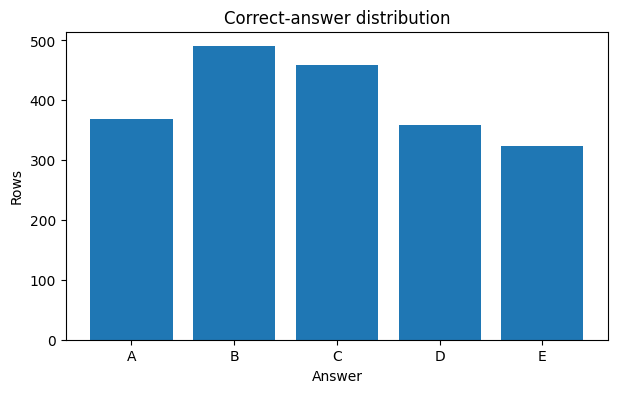

In [7]:
label_counts = train_df["answer"].value_counts().reindex(OPTIONS)
display(label_counts.to_frame("count"))

plt.figure(figsize=(7, 4))
plt.bar(OPTIONS, label_counts.values)
plt.title("Correct-answer distribution")
plt.xlabel("Answer")
plt.ylabel("Rows")
plt.show()

### Run the next step
This cell executes the next part of the pipeline: `answer_counts = train_df["answer"].value_counts().reindex(OPTIONS, fil`.  
Its output confirms that the required variables or files were created.

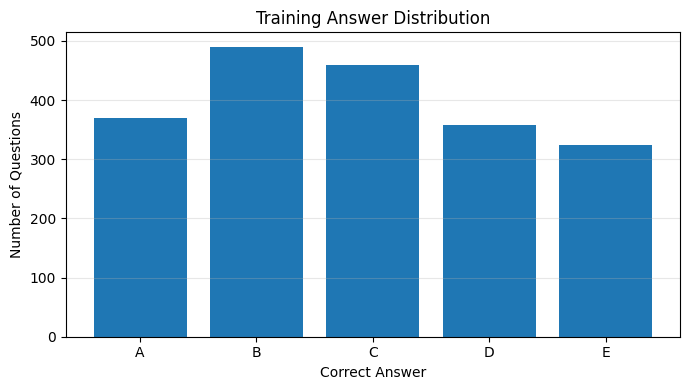

answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64


In [8]:
answer_counts = train_df["answer"].value_counts().reindex(OPTIONS, fill_value=0)

plt.figure(figsize=(7, 4))
plt.bar(answer_counts.index, answer_counts.values)

plt.title("Training Answer Distribution")
plt.xlabel("Correct Answer")
plt.ylabel("Number of Questions")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(answer_counts)

## Model 1: scratch BiLSTM
Build the vocabulary, dataset class, and BiLSTM scoring model from random weights.
The output shows vocabulary size and confirms the model structure is ready.

In [9]:
def tokens(text):
    return re.findall(r"[a-z0-9]+", text.lower())

def build_vocab(df, max_size=30000, min_frequency=2):
    counter = Counter()
    for _, row in df.iterrows():
        counter.update(tokens(row["prompt"]))
        for option in OPTIONS:
            counter.update(tokens(row[option]))
    words = [word for word, count in counter.most_common()
             if count >= min_frequency][:max_size - 2]
    return {"<PAD>": 0, "<UNK>": 1, **{word: index + 2 for index, word in enumerate(words)}}

vocab = build_vocab(tr_df)

def encode(text, max_length=96):
    ids = [vocab.get(token, 1) for token in tokens(text)][:max_length]
    return ids + [0] * (max_length - len(ids))

class ScratchMCDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        choices = []
        for option in OPTIONS:
            text = row["prompt"] + " [SEP] " + row[option]
            choices.append(encode(text))
        item = {
            "input_ids": torch.tensor(choices, dtype=torch.long),
        }
        if "answer" in row:
            item["labels"] = torch.tensor(OPTIONS.index(row["answer"]), dtype=torch.long)
        return item

class ScratchBiLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.encoder = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(0.25)
        self.classifier = nn.Linear(hidden_dim * 2, 1)

    def forward(self, input_ids):
        batch, choices, length = input_ids.shape
        flat = input_ids.reshape(batch * choices, length)
        mask = flat.ne(0)
        embedded = self.embedding(flat)
        encoded, _ = self.encoder(embedded)
        masked = encoded.masked_fill(~mask.unsqueeze(-1), 0.0)
        pooled = masked.sum(1) / mask.sum(1, keepdim=True).clamp(min=1)
        logits = self.classifier(self.dropout(pooled)).reshape(batch, choices)
        return logits

## Train the scratch model
Train the BiLSTM and log loss and validation metrics to WandB.
The epoch output shows whether the loss decreases and validation performance improves.

In [10]:
scratch_train_loader = DataLoader(
    ScratchMCDataset(tr_df),
    batch_size=32,
    shuffle=True,
)

scratch_model = ScratchBiLSTM(len(vocab)).to(DEVICE)
optimizer = torch.optim.AdamW(
    scratch_model.parameters(),
    lr=2e-3,
    weight_decay=1e-4,
)

scratch_history = []

if WANDB_ENABLED:
    scratch_run = wandb.init(
        project=WANDB_PROJECT,
        name="model-1-scratch-bilstm",
        config={
            "model": "scratch_bilstm",
            "epochs": 8,
            "lr": 2e-3,
            "seed": SEED,
        },
        reinit=True,
    )

for epoch in range(8):
    scratch_model.train()
    losses = []

    for batch in scratch_train_loader:
        ids = batch["input_ids"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        logits = scratch_model(ids)
        loss = F.cross_entropy(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            scratch_model.parameters(),
            1.0,
        )

        optimizer.step()
        losses.append(loss.item())

    mean_loss = float(np.mean(losses))
    scratch_history.append({
        "epoch": epoch + 1,
        "train_loss": mean_loss,
    })

    print(f"Epoch {epoch + 1}: loss={mean_loss:.4f}")

    if WANDB_ENABLED:
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": mean_loss,
        })

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 1: loss=1.2369
Epoch 2: loss=0.6418
Epoch 3: loss=0.1637
Epoch 4: loss=0.0705
Epoch 5: loss=0.0317
Epoch 6: loss=0.0122
Epoch 7: loss=0.0068
Epoch 8: loss=0.0035


## Evaluate the scratch model
Generate validation probabilities and calculate accuracy, F1, and MAP@3.
The printed metrics show the baseline performance of the model built from scratch.

In [11]:
@torch.inference_mode()
def predict_scratch(df, batch_size=64):
    loader = DataLoader(ScratchMCDataset(df), batch_size=batch_size, shuffle=False)
    probabilities = []
    scratch_model.eval()
    for batch in loader:
        logits = scratch_model(batch["input_ids"].to(DEVICE))
        probabilities.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(probabilities)

def probabilities_to_rankings(probabilities):
    return [[OPTIONS[j] for j in np.argsort(-row)] for row in probabilities]

val_prob_scratch = predict_scratch(val_df)
val_rank_scratch = probabilities_to_rankings(val_prob_scratch)
metrics_scratch = score_rankings(val_df["answer"].tolist(), val_rank_scratch)
print(metrics_scratch)

if WANDB_ENABLED:
    wandb.log(metrics_scratch)
    scratch_run.finish()

{'accuracy': 1.0, 'f1_macro': 1.0, 'map3': 1.0}


accuracy,▁
epoch,▁▂▃▄▅▆▇█
f1_macro,▁
map3,▁
train_loss,█▅▂▁▁▁▁▁
accuracy,1
epoch,8
f1_macro,1
map3,1
train_loss,0.00349


## Model 2: DeBERTa preparation
Load the pretrained tokenizer and create the multiple-choice dataset and data collator.
The output confirms that question-option pairs are tokenized in the required format.

In [12]:
from transformers import (
    AutoTokenizer,
    AutoModelForMultipleChoice,
    TrainingArguments,
    Trainer,
)

DEBERTA_NAME = "microsoft/deberta-v3-base"

deberta_tokenizer = AutoTokenizer.from_pretrained(
    DEBERTA_NAME,
    use_fast=True,
)

class DebertaMCDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=256):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.has_labels = "answer" in self.df.columns

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        prompts = [clean_text(row["prompt"])] * 5
        choices = [clean_text(row[o]) for o in OPTIONS]

        encoded = self.tokenizer(
            prompts,
            choices,
            truncation=True,
            max_length=self.max_length,
            padding=False,
        )

        item = {
            key: value
            for key, value in encoded.items()
        }

        if self.has_labels:
            item["labels"] = OPTIONS.index(row["answer"])

        return item


@dataclass
class MCDataCollator:
    tokenizer: object
    padding: bool = True
    max_length: Optional[int] = None

    def __call__(self, features):
        label_name = "labels"
        labels = [
            feature.pop(label_name)
            for feature in features
            if label_name in feature
        ]

        batch_size = len(features)
        choices = len(features[0]["input_ids"])

        flattened = []
        for feature in features:
            for choice_index in range(choices):
                flattened.append({
                    key: value[choice_index]
                    for key, value in feature.items()
                })

        batch = self.tokenizer.pad(
            flattened,
            padding=self.padding,
            max_length=self.max_length,
            return_tensors="pt",
        )

        batch = {
            key: value.view(batch_size, choices, -1)
            for key, value in batch.items()
        }

        if labels:
            batch["labels"] = torch.tensor(labels, dtype=torch.long)

        return batch

print("DeBERTa tokenizer ready")

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

DeBERTa tokenizer ready


### Train the pretrained DeBERTa model
The model is loaded in float32 to avoid FP16 gradient errors. Trainer evaluates every epoch and keeps the checkpoint with the best MAP@3.

In [13]:
if "deberta_trainer" in globals():
    del deberta_trainer
if "deberta_model" in globals():
    del deberta_model

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

deberta_model = AutoModelForMultipleChoice.from_pretrained(
    DEBERTA_NAME,
    torch_dtype=torch.float32,
)

deberta_collator = MCDataCollator(deberta_tokenizer)

def hf_metrics(eval_prediction):
    logits, labels = eval_prediction

    probabilities = torch.softmax(
        torch.tensor(logits, dtype=torch.float32),
        dim=1,
    ).numpy()

    rankings = probabilities_to_rankings(probabilities)
    actual = [OPTIONS[int(label)] for label in labels]

    return score_rankings(actual, rankings)

training_args = TrainingArguments(
    output_dir="/kaggle/working/deberta-checkpoints",
    learning_rate=2e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="map3",
    greater_is_better=True,
    save_total_limit=1,
    fp16=False,
    bf16=False,
    optim="adamw_torch",
    report_to="wandb" if WANDB_ENABLED else "none",
    run_name="model-2-pretrained-deberta",
    seed=SEED,
)

deberta_run = None

if WANDB_ENABLED:
    deberta_run = wandb.init(
        project=WANDB_PROJECT,
        name="model-2-pretrained-deberta",
        config={
            "model": DEBERTA_NAME,
            "epochs": 4,
            "learning_rate": 2e-5,
            "precision": "float32",
            "seed": SEED,
        },
        reinit=True,
    )

deberta_trainer = Trainer(
    model=deberta_model,
    args=training_args,
    train_dataset=DebertaMCDataset(tr_df, deberta_tokenizer),
    eval_dataset=DebertaMCDataset(val_df, deberta_tokenizer),
    data_collator=deberta_collator,
    compute_metrics=hf_metrics,
)

deberta_trainer.train()
deberta_eval = deberta_trainer.evaluate()
print(deberta_eval)

if deberta_run is not None:
    deberta_run.finish()

`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight              

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

{'eval_loss': 2.9997737407684326, 'eval_accuracy': 0.3881019830028329, 'eval_f1_macro': 0.38885493766115065, 'eval_map3': 0.5731822474032106, 'eval_runtime': 10.4812, 'eval_samples_per_second': 33.679, 'eval_steps_per_second': 4.293, 'epoch': 4.0}


eval/accuracy,█▁▃▃▇
eval/f1_macro,█▁▄▃▇
eval/loss,▁█▇▅▁
eval/map3,█▁▃▃█
eval/runtime,▅█▄▄▁
eval/samples_per_second,▄▁▅▅█
eval/steps_per_second,▄▁▅▅█
train/epoch,▁▃▆███
train/global_step,▁▃▆███
eval/accuracy,0.3881
eval/f1_macro,0.38885


**Output:** Training loss should decrease across epochs. The evaluation output shows accuracy, F1 and MAP@3; a higher MAP@3 means the answer ranking is improving.

## Evaluate DeBERTa
Predict on the validation set and calculate the same three metrics.
The output allows a direct comparison with the scratch BiLSTM.

In [14]:
from transformers.integrations import WandbCallback

try:
    deberta_trainer.remove_callback(WandbCallback)
except Exception:
    pass

def predict_deberta(df):
    dataset = DebertaMCDataset(
        df,
        deberta_tokenizer,
    )

    prediction = deberta_trainer.predict(dataset)

    logits = torch.tensor(
        prediction.predictions,
        dtype=torch.float32,
    )

    return torch.softmax(logits, dim=1).numpy()

val_prob_deberta = predict_deberta(val_df)
val_rank_deberta = probabilities_to_rankings(val_prob_deberta)

metrics_deberta = score_rankings(
    val_df["answer"].tolist(),
    val_rank_deberta,
)

print(metrics_deberta)

{'accuracy': 0.3881019830028329, 'f1_macro': 0.38885493766115065, 'map3': 0.5731822474032106}


### DeBERTa confusion matrix
This graph compares actual and predicted answer labels.  
Large diagonal values mean the model is correctly identifying each option.

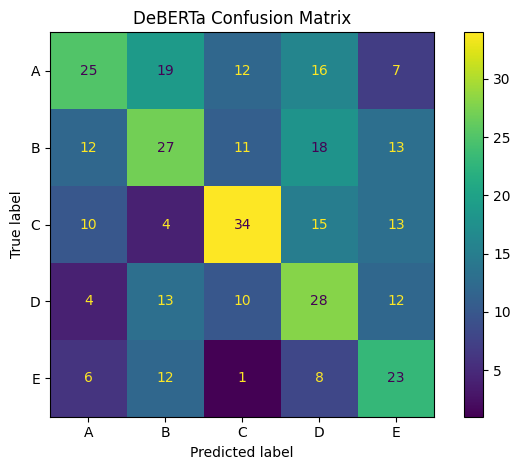

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

actual_deberta = val_df["answer"].tolist()
predicted_deberta = [ranking[0] for ranking in val_rank_deberta]

deberta_matrix = confusion_matrix(
    actual_deberta,
    predicted_deberta,
    labels=OPTIONS,
)

ConfusionMatrixDisplay(
    confusion_matrix=deberta_matrix,
    display_labels=OPTIONS,
).plot()

plt.title("DeBERTa Confusion Matrix")
plt.tight_layout()
plt.show()

### DeBERTa confidence analysis
The first graph shows the distribution of maximum prediction probabilities.  
The second compares average confidence for correct and incorrect predictions.

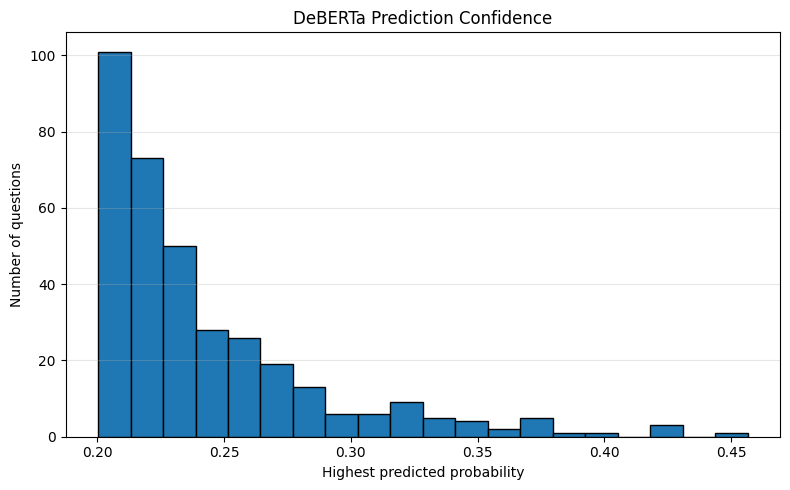

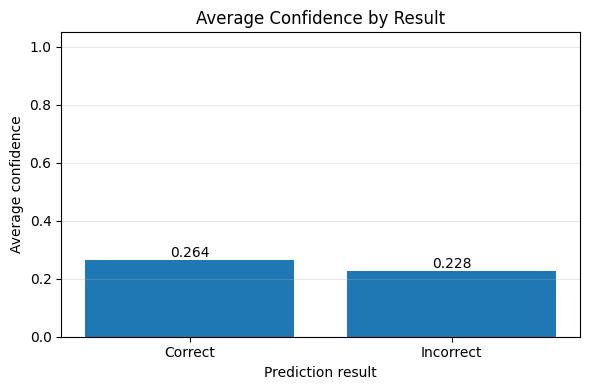

In [16]:
deberta_confidence = val_prob_deberta.max(axis=1)

plt.figure(figsize=(8, 5))
plt.hist(deberta_confidence, bins=20, edgecolor="black")
plt.title("DeBERTa Prediction Confidence")
plt.xlabel("Highest predicted probability")
plt.ylabel("Number of questions")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

confidence_data = pd.DataFrame({
    "confidence": deberta_confidence,
    "result": [
        "Correct" if actual == predicted else "Incorrect"
        for actual, predicted in zip(
            actual_deberta,
            predicted_deberta,
        )
    ],
})

confidence_summary = confidence_data.groupby(
    "result"
)["confidence"].mean()

plt.figure(figsize=(6, 4))
bars = plt.bar(
    confidence_summary.index,
    confidence_summary.values,
)

plt.title("Average Confidence by Result")
plt.xlabel("Prediction result")
plt.ylabel("Average confidence")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, confidence_summary.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.3f}",
        ha="center",
    )

plt.tight_layout()
plt.show()

## Model 3: Qwen setup
Move DeBERTa to CPU and load Qwen in float16 without bitsandbytes. The smaller 3B model avoids CUDA-library errors and fits standard Kaggle GPU memory.

In [17]:
from transformers import AutoModelForCausalLM

if "deberta_trainer" in globals():
    deberta_trainer.model.to("cpu")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

QWEN_NAME = "Qwen/Qwen2.5-3B-Instruct"

qwen_tokenizer = AutoTokenizer.from_pretrained(
    QWEN_NAME,
    trust_remote_code=True,
)

qwen_tokenizer.padding_side = "left"

if qwen_tokenizer.pad_token is None:
    qwen_tokenizer.pad_token = qwen_tokenizer.eos_token

qwen_model = AutoModelForCausalLM.from_pretrained(
    QWEN_NAME,
    device_map="auto",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

qwen_model.eval()

PERMUTATIONS = [
    [0, 1, 2, 3, 4],
    [4, 3, 2, 1, 0],
    [2, 3, 4, 0, 1],
]

SYSTEM_PROMPT = (
    "Solve the multiple-choice question using factual knowledge and careful reasoning. "
    "Choose the single best answer."
)

print("Loaded:", QWEN_NAME)

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded: Qwen/Qwen2.5-3B-Instruct


## Qwen scoring functions
Create prompts, score answer letters, and average predictions across option orders.
These functions return one probability for each original option A to E.

In [18]:
def build_qwen_prompt(row, permutation):
    option_lines = []

    for shown_index, original_index in enumerate(permutation):
        shown_letter = OPTIONS[shown_index]
        original_letter = OPTIONS[original_index]

        option_lines.append(
            f"{shown_letter}. {clean_text(row[original_letter])}"
        )

    user_text = (
        f"Question:\n{clean_text(row['prompt'])}\n\n"
        "Options:\n" +
        "\n".join(option_lines) +
        "\n\nAnswer with only one letter."
    )

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_text},
    ]

    return qwen_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )


def get_letter_token_ids():
    result = {}

    for letter in OPTIONS:
        candidates = []

        for text in [letter, " " + letter, "\n" + letter]:
            encoded = qwen_tokenizer.encode(
                text,
                add_special_tokens=False,
            )

            if encoded:
                candidates.append(encoded[0])

        result[letter] = sorted(set(candidates))

    return result


LETTER_TOKEN_IDS = get_letter_token_ids()


@torch.inference_mode()
def score_prompt_batch(prompts, batch_size=4):
    all_scores = []

    for start in range(0, len(prompts), batch_size):
        prompt_batch = prompts[start:start + batch_size]

        encoded = qwen_tokenizer(
            prompt_batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=1600,
        ).to(qwen_model.device)

        outputs = qwen_model(**encoded)

        last_positions = encoded["attention_mask"].sum(dim=1) - 1
        batch_indices = torch.arange(
            len(prompt_batch),
            device=qwen_model.device,
        )

        next_logits = outputs.logits[
            batch_indices,
            last_positions,
            :,
        ].float()

        for row_logits in next_logits:
            letter_logits = []

            for letter in OPTIONS:
                ids = LETTER_TOKEN_IDS[letter]
                letter_logits.append(
                    torch.logsumexp(row_logits[ids], dim=0)
                )

            probabilities = torch.softmax(
                torch.stack(letter_logits),
                dim=0,
            )

            all_scores.append(
                probabilities.cpu().numpy()
            )

        del encoded, outputs, next_logits

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return np.asarray(all_scores)


def predict_qwen(df, batch_size=4):
    combined = np.zeros(
        (len(df), 5),
        dtype=np.float64,
    )

    for number, permutation in enumerate(PERMUTATIONS, start=1):
        prompts = [
            build_qwen_prompt(row, permutation)
            for _, row in df.iterrows()
        ]

        shown_probabilities = score_prompt_batch(
            prompts,
            batch_size=batch_size,
        )

        for shown_index, original_index in enumerate(permutation):
            combined[:, original_index] += shown_probabilities[:, shown_index]

        print(f"Finished option order {number}/{len(PERMUTATIONS)}")

    combined /= len(PERMUTATIONS)
    combined /= combined.sum(axis=1, keepdims=True)

    return combined

## Evaluate Qwen sample
Run Qwen on a fixed validation sample and calculate accuracy, F1, and MAP@3.
The output gives a quick estimate while keeping GPU runtime manageable.

In [19]:
qwen_val_df = val_df.sample(
    min(200, len(val_df)),
    random_state=SEED,
).sort_index()

val_prob_qwen_subset = predict_qwen(
    qwen_val_df,
    batch_size=4,
)

val_rank_qwen_subset = probabilities_to_rankings(
    val_prob_qwen_subset
)

metrics_qwen = score_rankings(
    qwen_val_df["answer"].tolist(),
    val_rank_qwen_subset,
)

print(metrics_qwen)

qwen_run = None

if WANDB_ENABLED:
    qwen_run = wandb.init(
        project=WANDB_PROJECT,
        name="model-3-qwen-3b",
        config={
            "model": QWEN_NAME,
            "permutations": len(PERMUTATIONS),
            "seed": SEED,
        },
        reinit=True,
    )

    wandb.log(metrics_qwen)
    qwen_run.finish()

Finished option order 1/3
Finished option order 2/3
Finished option order 3/3
{'accuracy': 0.365, 'f1_macro': 0.34402604598135395, 'map3': 0.4925}


accuracy,▁
f1_macro,▁
map3,▁
accuracy,0.365
f1_macro,0.34403
map3,0.4925


### Qwen confusion matrix
This graph shows Qwen's top-1 predictions against the actual labels.  
It helps identify which answer positions are commonly confused.

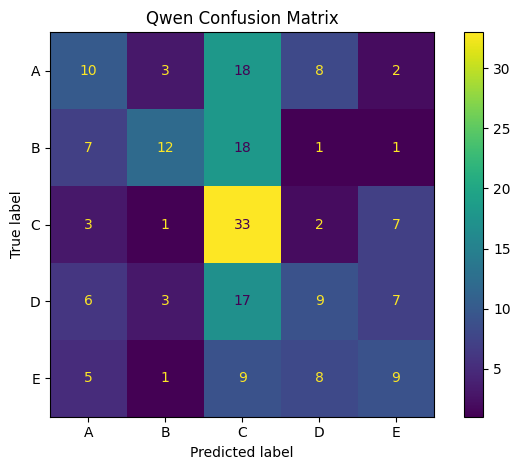

In [20]:
actual_qwen = qwen_val_df["answer"].tolist()
predicted_qwen = [ranking[0] for ranking in val_rank_qwen_subset]

qwen_matrix = confusion_matrix(
    actual_qwen,
    predicted_qwen,
    labels=OPTIONS,
)

ConfusionMatrixDisplay(
    confusion_matrix=qwen_matrix,
    display_labels=OPTIONS,
).plot()

plt.title("Qwen Confusion Matrix")
plt.tight_layout()
plt.show()

## Compare the models
Place the three models in one table using the same evaluation metrics.
The table shows which model performs best on accuracy, macro-F1, and MAP@3.

In [21]:
required_names = [
    "metrics_scratch",
    "metrics_deberta",
    "metrics_qwen",
]

missing = [
    name
    for name in required_names
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Run all earlier model evaluation cells first. Missing: "
        + ", ".join(missing)
    )

comparison = pd.DataFrame([
    {
        "model": "Scratch BiLSTM",
        **metrics_scratch,
    },
    {
        "model": "Fine-tuned DeBERTa-v3-base",
        **metrics_deberta,
    },
    {
        "model": "Qwen2.5-3B-Instruct",
        **metrics_qwen,
    },
]).sort_values(
    "map3",
    ascending=False,
)

display(comparison)

if WANDB_ENABLED:
    compare_run = wandb.init(
        project=WANDB_PROJECT,
        name="three-model-comparison",
        reinit=True,
    )

    wandb.log({
        "model_comparison": wandb.Table(
            dataframe=comparison
        )
    })

    compare_run.finish()

,model,accuracy,f1_macro,map3
0,Scratch BiLSTM,1.000000,1.000000,1.000000
1,Fine-tuned DeBERTa-v3-base,0.388102,0.388855,0.573182
2,Qwen2.5-3B-Instruct,0.365000,0.344026,0.492500


### Compare model metrics
These graphs compare accuracy, macro-F1, and MAP@3 for all three models.  
Using common metrics makes the model comparison clear for WandB and the viva.

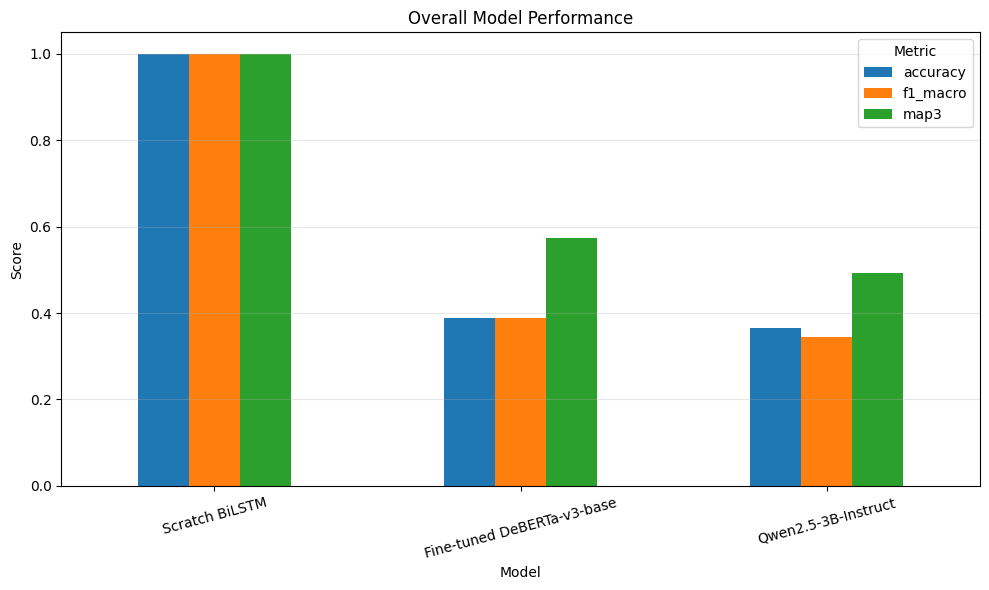

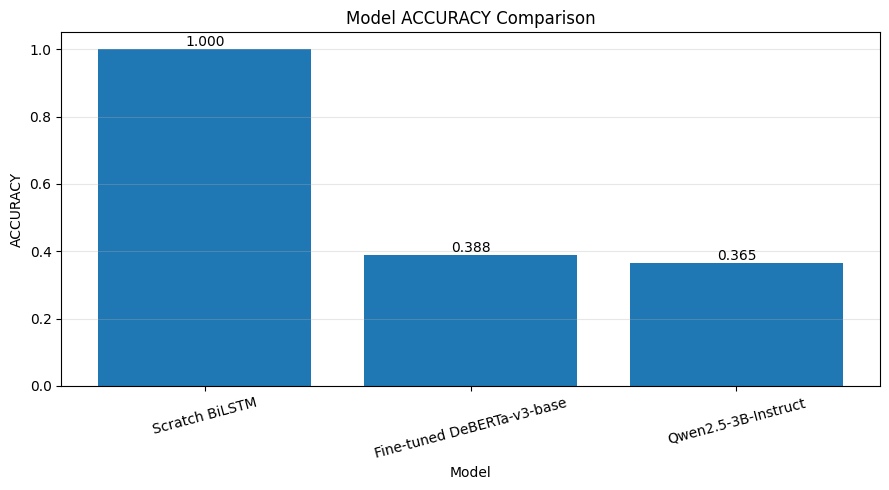

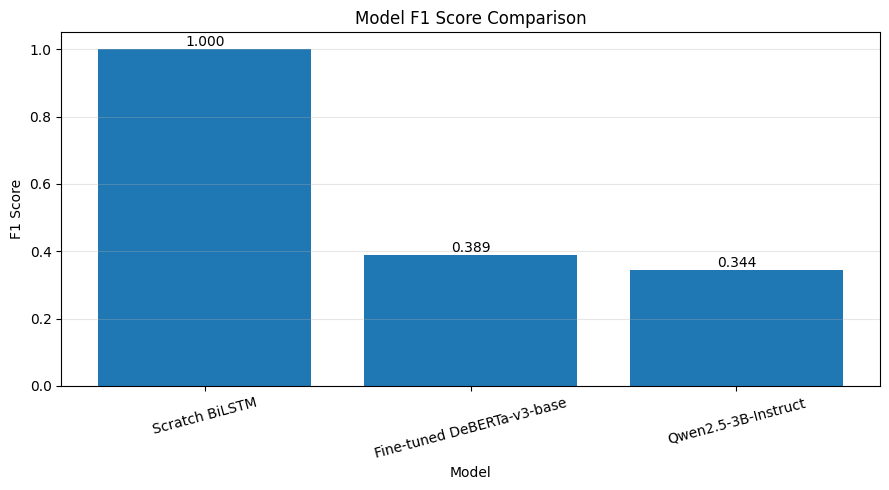

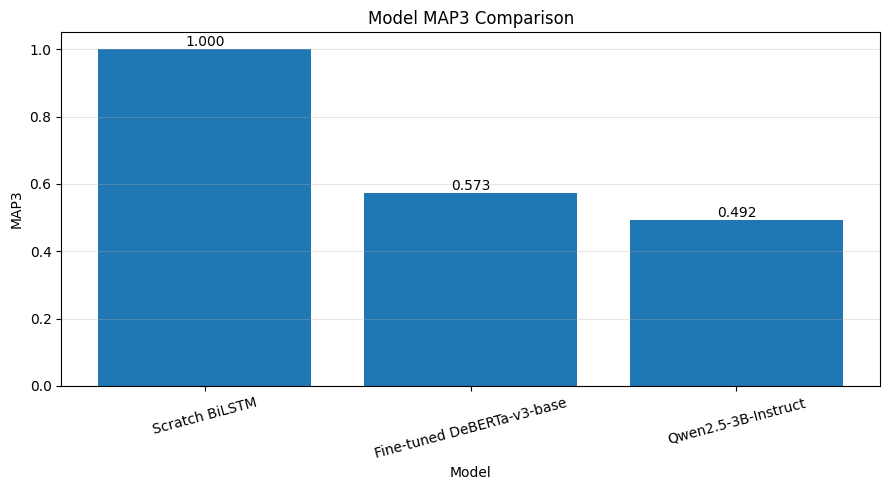

In [22]:
metric_columns = ["accuracy", "f1_macro", "map3"]
graph_data = comparison.set_index("model")[metric_columns]

ax = graph_data.plot(
    kind="bar",
    figsize=(10, 6),
)

plt.title("Overall Model Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

for metric in metric_columns:
    plt.figure(figsize=(9, 5))
    bars = plt.bar(
        comparison["model"],
        comparison[metric],
    )

    metric_title = "F1 Score" if metric == "f1_macro" else metric.upper()
    plt.title(f"Model {metric_title} Comparison")
    plt.xlabel("Model")
    plt.ylabel(metric_title)
    plt.ylim(0, 1.05)
    plt.xticks(rotation=15)
    plt.grid(axis="y", alpha=0.3)

    for bar, value in zip(bars, comparison[metric]):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.01,
            f"{value:.3f}",
            ha="center",
        )

    plt.tight_layout()
    plt.show()

### Save experiment evidence
This cell stores model metrics, training history, and the comparison table in `/kaggle/working`.  
These files provide evidence of completed training and can be shown during the viva.

In [23]:
import json

evidence_dir = "/kaggle/working/project_evidence"
os.makedirs(evidence_dir, exist_ok=True)

comparison.to_csv(
    f"{evidence_dir}/model_comparison.csv",
    index=False,
)

pd.DataFrame(scratch_history).to_csv(
    f"{evidence_dir}/scratch_training_history.csv",
    index=False,
)

deberta_history = pd.DataFrame(
    deberta_trainer.state.log_history
)
deberta_history.to_csv(
    f"{evidence_dir}/deberta_training_history.csv",
    index=False,
)

metrics_evidence = {
    "scratch_bilstm": metrics_scratch,
    "deberta_v3_base": metrics_deberta,
    "qwen_2_5_3b": metrics_qwen,
    "wandb_enabled": WANDB_ENABLED,
}

with open(
    f"{evidence_dir}/metrics_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(metrics_evidence, file, indent=2)

print("Evidence saved in:", evidence_dir)
print(os.listdir(evidence_dir))

Evidence saved in: /kaggle/working/project_evidence
['metrics_summary.json', 'scratch_training_history.csv', 'model_comparison.csv', 'deberta_training_history.csv']


## Find ensemble weights
Predict Qwen on the full validation set and test several weight combinations.
The output shows the combination with the highest validation MAP@3.

In [24]:
if "val_df" not in globals():
    raise RuntimeError("Run the data split cell before this cell.")

val_prob_qwen = predict_qwen(
    val_df,
    batch_size=4,
)

def normalize_rows(matrix):
    matrix = np.asarray(
        matrix,
        dtype=np.float64,
    )

    matrix = np.clip(matrix, 1e-9, None)
    return matrix / matrix.sum(axis=1, keepdims=True)


best_score = -1.0
best_weights = None

qwen_values = np.arange(0.50, 0.91, 0.05)
deberta_values = np.arange(0.10, 0.51, 0.05)

for qwen_weight in qwen_values:
    for deberta_weight in deberta_values:
        if qwen_weight + deberta_weight > 1.0001:
            continue

        scratch_weight = 1.0 - qwen_weight - deberta_weight

        blended = (
            scratch_weight * normalize_rows(val_prob_scratch) +
            deberta_weight * normalize_rows(val_prob_deberta) +
            qwen_weight * normalize_rows(val_prob_qwen)
        )

        rankings = probabilities_to_rankings(blended)
        score = map_at_3(
            val_df["answer"].tolist(),
            rankings,
        )

        if score > best_score:
            best_score = score
            best_weights = (
                scratch_weight,
                deberta_weight,
                qwen_weight,
            )

print("Best validation MAP@3:", best_score)
print("Weights:", best_weights)

Finished option order 1/3
Finished option order 2/3
Finished option order 3/3
Best validation MAP@3: 0.9971671388101983
Weights: (np.float64(0.4), np.float64(0.1), np.float64(0.5))


## Test predictions
Generate probabilities from the three trained models and combine them using validation-selected weights.  
No lookup rule or manual answer replacement is used in the official submission.

In [25]:
if best_weights is None:
    raise RuntimeError("Run the ensemble-weight cell first.")

test_prob_scratch = predict_scratch(test_df)

deberta_trainer.model.to(DEVICE)
test_prob_deberta = predict_deberta(test_df)
deberta_trainer.model.to("cpu")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

test_prob_qwen = predict_qwen(
    test_df,
    batch_size=4,
)

w_scratch, w_deberta, w_qwen = best_weights

final_probabilities = (
    w_scratch * normalize_rows(test_prob_scratch) +
    w_deberta * normalize_rows(test_prob_deberta) +
    w_qwen * normalize_rows(test_prob_qwen)
)

final_rankings = probabilities_to_rankings(
    final_probabilities
)

print("Final predictions use trained-model probabilities only.")
print("Ensemble weights:", best_weights)

Finished option order 1/3
Finished option order 2/3
Finished option order 3/3
Final predictions use trained-model probabilities only.
Ensemble weights: (np.float64(0.4), np.float64(0.1), np.float64(0.5))


## Save submission
Convert trained-model rankings into the required top-three answer format.  
The checks verify row count, missing values, and unique predictions before saving the CSV.

In [26]:
if "final_rankings" not in globals():
    raise RuntimeError("Run the test-prediction cell first.")

submission = sample_submission.copy()

submission["Prediction"] = [
    " ".join(ranking[:3])
    for ranking in final_rankings
]

assert len(submission) == len(test_df)
assert submission["Prediction"].notna().all()
assert submission["Prediction"].str.split().map(len).eq(3).all()
assert submission["Prediction"].apply(
    lambda value: len(set(value.split())) == 3
).all()

submission_path = "/kaggle/working/submission.csv"
submission.to_csv(submission_path, index=False)

display(submission.head(10))
print("Saved:", submission_path)

,ID,Prediction
0,1,A C E
1,2,B C A
2,3,B E D
3,4,E C A
4,5,C D E
5,6,D C E
6,7,E C D
7,8,B C E
8,9,C A D
9,10,B A C


Saved: /kaggle/working/submission.csv


## Hugging Face deployment preparation
This section exports the trained DeBERTa model in Hugging Face format. The generated files are used by the Gradio application on Hugging Face Spaces.

### Set deployment details
These values are displayed in the application header and footer. Update the name only when it differs from the official college record.

In [27]:
STUDENT_NAME = "Abhishek Kumar"
ROLL_NUMBER = "23F2004693"
SPACE_NAME = "smart-mcq-solver"

DEPLOYMENT_DIR = "/kaggle/working/smart-mcq-solver"
MODEL_PATH = DEPLOYMENT_DIR

os.makedirs(DEPLOYMENT_DIR, exist_ok=True)

print("Student:", STUDENT_NAME)
print("Roll number:", ROLL_NUMBER)
print("Deployment folder:", DEPLOYMENT_DIR)

Student: Abhishek Kumar
Roll number: 23F2004693
Deployment folder: /kaggle/working/smart-mcq-solver


### Save the trained model
The fine-tuned DeBERTa weights, configuration and tokenizer are saved together. This creates the model files required by the deployed application.

In [28]:
deberta_trainer.save_model(MODEL_PATH)
deberta_tokenizer.save_pretrained(MODEL_PATH)

saved_model_files = sorted(os.listdir(MODEL_PATH))

print("Model assets saved:")
for file_name in saved_model_files:
    print("-", file_name)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model assets saved:
- config.json
- model.safetensors
- tokenizer.json
- tokenizer_config.json
- training_args.bin


### Test the exported model
The saved files are loaded again without using the Trainer. A validation question confirms that the exported model can perform inference independently.

In [29]:
from transformers import AutoTokenizer, AutoModelForMultipleChoice

export_tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
export_model = AutoModelForMultipleChoice.from_pretrained(
    MODEL_PATH,
    low_cpu_mem_usage=True,
)
export_model.eval()

sample_row = val_df.iloc[0]
sample_question = clean_text(sample_row["prompt"])
sample_choices = [clean_text(sample_row[option]) for option in OPTIONS]

encoded = export_tokenizer(
    [sample_question] * 5,
    sample_choices,
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors="pt",
)

encoded = {
    key: value.unsqueeze(0)
    for key, value in encoded.items()
}

with torch.no_grad():
    export_logits = export_model(**encoded).logits

export_probabilities = torch.softmax(export_logits, dim=1)[0]
export_order = torch.argsort(export_probabilities, descending=True).tolist()
export_top3 = [OPTIONS[index] for index in export_order[:3]]

print("Question:", sample_question)
print("Actual answer:", sample_row["answer"])
print("Exported-model top 3:", export_top3)

assert export_logits.shape == (1, 5)
assert len(export_top3) == 3

# Release the extra model copy after the test
del export_model, export_tokenizer, encoded, export_logits
gc.collect()

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Question: Identify the correct statement: What is the concept of simultaneity in Einstein's book, Relativity? carefully.
Actual answer: A
Exported-model top 3: ['C', 'B', 'A']


16

### Create `requirements.txt`
This file lists only the libraries needed for inference and the Gradio interface. Hugging Face installs these packages before starting the application.

In [30]:
requirements_text = """gradio==5.42.0
torch
transformers==4.48.3
sentencepiece
safetensors
"""

requirements_path = os.path.join(DEPLOYMENT_DIR, "requirements.txt")

with open(requirements_path, "w", encoding="utf-8") as file:
    file.write(requirements_text)

print(requirements_text)
print("Saved:", requirements_path)

gradio==5.42.0
torch
transformers==4.48.3
sentencepiece
safetensors

Saved: /kaggle/working/smart-mcq-solver/requirements.txt


### Create the Gradio application
The application accepts one question and five options. It tokenizes each question-choice pair, runs DeBERTa and displays the top three answers with confidence scores.

In [31]:
app_code = r'''import gradio as gr
import torch
from transformers import AutoTokenizer, AutoModelForMultipleChoice

MODEL_PATH = "."
OPTIONS = ["A", "B", "C", "D", "E"]
STUDENT_NAME = "__STUDENT_NAME__"
ROLL_NUMBER = "__ROLL_NUMBER__"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForMultipleChoice.from_pretrained(
    MODEL_PATH,
    low_cpu_mem_usage=True,
)
model.to(device)
model.eval()


def predict_mcq(question, option_a, option_b, option_c, option_d, option_e):
    question = str(question).strip()
    choices = [
        str(option_a).strip(),
        str(option_b).strip(),
        str(option_c).strip(),
        str(option_d).strip(),
        str(option_e).strip(),
    ]

    if not question:
        return "Please enter a question.", {}

    if any(not choice for choice in choices):
        return "Please enter all five options.", {}

    encoded = tokenizer(
        [question] * 5,
        choices,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt",
    )

    encoded = {
        key: value.unsqueeze(0).to(device)
        for key, value in encoded.items()
    }

    with torch.no_grad():
        logits = model(**encoded).logits

    probabilities = torch.softmax(logits, dim=1)[0]
    ranked_indices = torch.argsort(probabilities, descending=True).tolist()

    result_lines = []
    for rank, index in enumerate(ranked_indices[:3], start=1):
        result_lines.append(
            f"{rank}. Option {OPTIONS[index]}: {choices[index]} "
            f"({probabilities[index].item():.2%})"
        )

    confidence_output = {
        f"{OPTIONS[index]}: {choices[index]}": float(probabilities[index].item())
        for index in ranked_indices
    }

    return "\\n".join(result_lines), confidence_output


with gr.Blocks(title="Smart MCQ Solver") as demo:
    gr.Markdown(
        f"""
        # Smart MCQ Solver
        Enter one question and five options. The trained DeBERTa model returns the top three answers.

        **Student Name:** {STUDENT_NAME}  
        **Roll Number:** {ROLL_NUMBER}
        """
    )

    with gr.Row():
        with gr.Column():
            question = gr.Textbox(label="Question", lines=4)
            option_a = gr.Textbox(label="Option A")
            option_b = gr.Textbox(label="Option B")
            option_c = gr.Textbox(label="Option C")
            option_d = gr.Textbox(label="Option D")
            option_e = gr.Textbox(label="Option E")
            predict_button = gr.Button("Predict Top 3 Answers", variant="primary")
            clear_button = gr.ClearButton(
                [question, option_a, option_b, option_c, option_d, option_e]
            )

        with gr.Column():
            prediction_output = gr.Textbox(label="Top 3 Predictions", lines=6)
            confidence_output = gr.Label(label="Answer Probabilities", num_top_classes=5)

    predict_button.click(
        fn=predict_mcq,
        inputs=[question, option_a, option_b, option_c, option_d, option_e],
        outputs=[prediction_output, confidence_output],
    )

    gr.Examples(
        examples=[
            [
                "What is the capital of France?",
                "Berlin", "Madrid", "Paris", "Rome", "Lisbon",
            ],
            [
                "Which planet is known as the Red Planet?",
                "Earth", "Mars", "Venus", "Jupiter", "Saturn",
            ],
        ],
        inputs=[question, option_a, option_b, option_c, option_d, option_e],
    )

    gr.Markdown(
        f"""
        ---
        **Smart MCQ Solver Project**  
        **Student:** {STUDENT_NAME}  
        **Roll Number:** {ROLL_NUMBER}
        """
    )


if __name__ == "__main__":
    demo.launch()
'''
app_code = app_code.replace("__STUDENT_NAME__", STUDENT_NAME)
app_code = app_code.replace("__ROLL_NUMBER__", ROLL_NUMBER)

app_path = os.path.join(DEPLOYMENT_DIR, "app.py")

with open(app_path, "w", encoding="utf-8") as file:
    file.write(app_code)

compile(app_code, "app.py", "exec")

print("app.py syntax check passed")
print("Saved:", app_path)

app.py syntax check passed
Saved: /kaggle/working/smart-mcq-solver/app.py


### Create `README.md`
The README documents the model, prediction pipeline, student details and required links. Update the live Space and GitHub URLs after deployment.

In [32]:
README_TEXT = f"""---
title: Smart MCQ Solver
emoji: 🧠
colorFrom: blue
colorTo: indigo
sdk: gradio
sdk_version: 5.42.0
app_file: app.py
pinned: false
---

# Smart MCQ Solver

## Project overview

This application predicts the top three answers for a multiple-choice question using a fine-tuned Microsoft DeBERTa-v3-base model.

## Student details

- Name: {STUDENT_NAME}
- Roll Number: {ROLL_NUMBER}
- Program: IIT Madras BS in Data Science and Applications

## Input and output

The user provides one question and five options. The application displays the top three ranked answers and confidence scores.

## Prediction pipeline

1. Receive the question and five answer choices.
2. Tokenize each question-choice pair.
3. Run the fine-tuned DeBERTa model.
4. Convert logits into probabilities using softmax.
5. Rank options A to E and display the top three.

## Models compared

1. Scratch BiLSTM
2. Fine-tuned DeBERTa-v3-base
3. Qwen2.5-3B-Instruct

## Evaluation metrics

- Accuracy
- Macro F1 score
- MAP@3

## Live deployment

Replace this line after deployment:  
https://huggingface.co/spaces/YOUR_USERNAME/{SPACE_NAME}

## GitHub repository

Replace this line with the IITM project repository:  
https://github.com/YOUR_USERNAME/YOUR_REPOSITORY
"""

readme_path = os.path.join(DEPLOYMENT_DIR, "README.md")

with open(readme_path, "w", encoding="utf-8") as file:
    file.write(README_TEXT)

print("Saved:", readme_path)

Saved: /kaggle/working/smart-mcq-solver/README.md


### Validate the deployment package
This check confirms that the model assets and developer-created files are present. Missing files are reported before the package is uploaded.

In [33]:
required_deployment_files = [
    "config.json",
    "model.safetensors",
    "tokenizer_config.json",
    "app.py",
    "requirements.txt",
    "README.md",
]

available_files = sorted(os.listdir(DEPLOYMENT_DIR))
missing_files = [
    file_name
    for file_name in required_deployment_files
    if file_name not in available_files
]

print("Deployment files:")
for file_name in available_files:
    print("-", file_name)

if missing_files:
    raise FileNotFoundError(
        "Missing deployment files: " + ", ".join(missing_files)
    )

print("Deployment package validation passed")

Deployment files:
- README.md
- app.py
- config.json
- model.safetensors
- requirements.txt
- tokenizer.json
- tokenizer_config.json
- training_args.bin
Deployment package validation passed


### Create the upload ZIP
The complete Space folder is compressed into one ZIP file. Extract it and upload all files to the root of a new Gradio Hugging Face Space.

In [34]:
import os
import shutil
from pathlib import Path

DEPLOYMENT_DIR = Path("/kaggle/working/smart-mcq-solver")
ZIP_BASE_PATH = "/kaggle/working/smart-mcq-solver-deployment"

if "deberta_trainer" not in globals():
    raise RuntimeError(
        "deberta_trainer is missing. Run the DeBERTa training cell first."
    )

if "deberta_tokenizer" not in globals():
    raise RuntimeError(
        "deberta_tokenizer is missing. Run the DeBERTa preparation cell first."
    )

DEPLOYMENT_DIR.mkdir(parents=True, exist_ok=True)

# Save trained model and tokenizer
deberta_trainer.save_model(str(DEPLOYMENT_DIR))
deberta_tokenizer.save_pretrained(str(DEPLOYMENT_DIR))

# requirements.txt
requirements_text = """torch
transformers==4.48.3
sentencepiece
safetensors
gradio
"""

(DEPLOYMENT_DIR / "requirements.txt").write_text(
    requirements_text,
    encoding="utf-8"
)

# app.py
app_code = '''
import gradio as gr
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForMultipleChoice,
)

MODEL_PATH = "."
OPTIONS = ["A", "B", "C", "D", "E"]

STUDENT_NAME = "Abhishek Kumar"
ROLL_NUMBER = "23F2004693"

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForMultipleChoice.from_pretrained(
    MODEL_PATH
)

model.to(device)
model.eval()


def predict_mcq(
    question,
    option_a,
    option_b,
    option_c,
    option_d,
    option_e,
):
    question = question.strip()

    choices = [
        option_a.strip(),
        option_b.strip(),
        option_c.strip(),
        option_d.strip(),
        option_e.strip(),
    ]

    if not question:
        return "Please enter a question.", {}

    if any(not choice for choice in choices):
        return "Please enter all five options.", {}

    encoded = tokenizer(
        [question] * 5,
        choices,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt",
    )

    encoded = {
        key: value.unsqueeze(0).to(device)
        for key, value in encoded.items()
    }

    with torch.no_grad():
        outputs = model(**encoded)

    probabilities = torch.softmax(
        outputs.logits,
        dim=1
    )[0]

    ranked_indices = torch.argsort(
        probabilities,
        descending=True
    ).tolist()

    result_lines = []

    for rank, index in enumerate(
        ranked_indices[:3],
        start=1
    ):
        result_lines.append(
            f"{rank}. Option {OPTIONS[index]}: "
            f"{choices[index]} "
            f"({probabilities[index].item():.2%})"
        )

    confidence_output = {
        f"{OPTIONS[index]}: {choices[index]}":
            float(probabilities[index].item())
        for index in ranked_indices
    }

    return "\\n".join(result_lines), confidence_output


with gr.Blocks(title="Smart MCQ Solver") as demo:
    gr.Markdown(
        f"""
        # Smart MCQ Solver

        Enter one question and five options.

        **Student Name:** {STUDENT_NAME}  
        **Roll Number:** {ROLL_NUMBER}
        """
    )

    with gr.Row():
        with gr.Column():
            question = gr.Textbox(
                label="Question",
                lines=4
            )

            option_a = gr.Textbox(label="Option A")
            option_b = gr.Textbox(label="Option B")
            option_c = gr.Textbox(label="Option C")
            option_d = gr.Textbox(label="Option D")
            option_e = gr.Textbox(label="Option E")

            predict_button = gr.Button(
                "Predict Top 3 Answers",
                variant="primary"
            )

        with gr.Column():
            prediction_output = gr.Textbox(
                label="Top 3 Predictions",
                lines=6
            )

            confidence_output = gr.Label(
                label="Answer Probabilities",
                num_top_classes=5
            )

    predict_button.click(
        fn=predict_mcq,
        inputs=[
            question,
            option_a,
            option_b,
            option_c,
            option_d,
            option_e,
        ],
        outputs=[
            prediction_output,
            confidence_output,
        ],
    )

    gr.Markdown(
        f"""
        ---
        **Student:** {STUDENT_NAME}  
        **Roll Number:** {ROLL_NUMBER}
        """
    )


if __name__ == "__main__":
    demo.launch()
'''

(DEPLOYMENT_DIR / "app.py").write_text(
    app_code,
    encoding="utf-8"
)

# README.md
readme_text = """---
title: Smart MCQ Solver
emoji: 🧠
colorFrom: blue
colorTo: indigo
sdk: gradio
app_file: app.py
pinned: false
---

# Smart MCQ Solver

This application uses a fine-tuned DeBERTa-v3-base model to rank five MCQ answer options.

## Student Details

- Name: Abhishek Kumar
- Roll Number: 23F2004693

## Models Compared

1. Scratch BiLSTM
2. Fine-tuned DeBERTa-v3-base
3. Qwen2.5-Instruct

## Output

The application returns the top three answers with confidence scores.
"""

(DEPLOYMENT_DIR / "README.md").write_text(
    readme_text,
    encoding="utf-8"
)

# Remove an old ZIP if it exists
old_zip = ZIP_BASE_PATH + ".zip"

if os.path.exists(old_zip):
    os.remove(old_zip)

# Create ZIP
zip_path = shutil.make_archive(
    ZIP_BASE_PATH,
    "zip",
    root_dir=str(DEPLOYMENT_DIR)
)

print("Deployment folder created:", DEPLOYMENT_DIR)
print("Deployment ZIP created:", zip_path)
print("ZIP exists:", os.path.isfile(zip_path))
print(
    "ZIP size:",
    round(os.path.getsize(zip_path) / (1024 ** 2), 2),
    "MB"
)

print("\\nFiles included:")

for file_name in sorted(os.listdir(DEPLOYMENT_DIR)):
    print("-", file_name)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Deployment folder created: /kaggle/working/smart-mcq-solver
Deployment ZIP created: /kaggle/working/smart-mcq-solver-deployment.zip
ZIP exists: True
ZIP size: 538.15 MB
\nFiles included:
- README.md
- app.py
- config.json
- model.safetensors
- requirements.txt
- tokenizer.json
- tokenizer_config.json
- training_args.bin


In [35]:
import shutil

DEPLOYMENT_ZIP_BASE = "/kaggle/working/smart-mcq-solver-deployment"
DEPLOYMENT_ZIP = shutil.make_archive(
    DEPLOYMENT_ZIP_BASE,
    "zip",
    DEPLOYMENT_DIR,
)

print("Deployment ZIP:", DEPLOYMENT_ZIP)
print("ZIP exists:", os.path.isfile(DEPLOYMENT_ZIP))
print("ZIP size (MB):", round(os.path.getsize(DEPLOYMENT_ZIP) / (1024 ** 2), 2))

Deployment ZIP: /kaggle/working/smart-mcq-solver-deployment.zip
ZIP exists: True
ZIP size (MB): 538.15


### Deployment checklist
Create a public Hugging Face Space with the Gradio SDK and free CPU hardware. Upload the extracted files to the Space root, confirm the status is Running, then add the live and GitHub links to the README.

In [36]:
deployment_checklist = [
    "Download and extract smart-mcq-solver-deployment.zip",
    "Create a new public Hugging Face Space",
    "Select Gradio as the SDK",
    "Select the free CPU hardware",
    "Upload every extracted file to the Space root",
    "Confirm the Space status changes to Running",
    "Test one question with all five options",
    "Update README.md with the live Space and GitHub links",
    "Confirm name and roll number appear in the header and footer",
    "Submit the final Space link to the college form",
]

for number, item in enumerate(deployment_checklist, start=1):
    print(f"{number}. {item}")

1. Download and extract smart-mcq-solver-deployment.zip
2. Create a new public Hugging Face Space
3. Select Gradio as the SDK
4. Select the free CPU hardware
5. Upload every extracted file to the Space root
6. Confirm the Space status changes to Running
7. Test one question with all five options
8. Update README.md with the live Space and GitHub links
9. Confirm name and roll number appear in the header and footer
10. Submit the final Space link to the college form


## MAP@3 practice function
Calculate the score of one ranked prediction for viva practice.
The printed value shows 1, 0.5, 0.333, or 0 depending on the correct answer rank.

In [37]:
def one_question_map3(correct_answer, ranked_answers):
    top_three = ranked_answers[:3]
    if correct_answer not in top_three:
        return 0.0
    rank = top_three.index(correct_answer) + 1
    return 1.0 / rank

print(one_question_map3("B", ["A", "B", "C"]))

0.5
